# Práctica 4: Razonamiento Basado en Casos con CBRkit

## Ingeniería del Conocimiento    2025/2026
### Prof. Juan A. Recio García

---

## Introducción

El **Razonamiento Basado en Casos (CBR)** es un paradigma de IA que resuelve nuevos problemas reutilizando soluciones de problemas similares del pasado. El ciclo CBR se compone de cuatro etapas:

1. **Retrieve** – Recuperar los casos más similares al problema actual.
2. **Reuse** – Adaptar la solución del caso recuperado al nuevo problema.
3. **Revise** – Evaluar y corregir la solución propuesta.
4. **Retain** – Almacenar el nuevo caso resuelto en la base de casos.

En esta práctica trabajaremos con la librería **CBRkit** para construir un sistema CBR aplicado a la **recomendación de coches de segunda mano**. Dado el perfil de un usuario que busca un coche, el sistema recuperará los vehículos más similares de la base de casos y adaptará el precio estimado.


---

## Dataset: Used Cars

Utilizaremos un subconjunto del dataset de coches de segunda mano disponible en Kaggle:  
🔗 https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data

Cada caso representa un vehículo con los siguientes atributos:

| Atributo | Tipo | Descripción |
|---|---|---|
| `price` | Numérico | Precio en dólares (solución / target) |
| `year` | Numérico | Año de fabricación |
| `odometer` | Numérico | Kilometraje |
| `manufacturer` | Categórico | Marca del fabricante |
| `fuel` | Categórico | Tipo de combustible |
| `transmission` | Categórico | Tipo de transmisión |
| `condition` | Categórico | Estado del vehículo |
| `model` | Cadena | Modelo del vehículo |
| `title_status` | Categórico | Estado del título de propiedad |

> **Nota:** En CBR, el atributo `price` representa la **solución** del caso. Los demás atributos forman la **descripción del problema**.


---
## Parte 0: Instalación y preparación del entorno

Ejecuta la siguiente celda para importar CBRkit y sus dependencias necesarias.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cbrkit as cbr


---
## Parte 1: Carga y exploración del dataset

Construiremos un dataset sintético pero realista de coches de segunda mano, representativo del original de Kaggle. Esto permite trabajar sin necesidad de cuenta en Kaggle.

In [3]:
# Dataset sintético de coches de segunda mano
# Inspirado en: https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data

np.random.seed(42)

data = [
    {"id": 1,  "year": 2018, "manufacturer": "toyota",    "model": "camry se",           "condition": "good",       "odometer": 45000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 18500},
    {"id": 2,  "year": 2016, "manufacturer": "honda",     "model": "civic lx",           "condition": "good",       "odometer": 62000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 14200},
    {"id": 3,  "year": 2020, "manufacturer": "ford",      "model": "f-150 xlt",          "condition": "excellent",  "odometer": 15000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 32000},
    {"id": 4,  "year": 2015, "manufacturer": "chevrolet", "model": "silverado 1500",     "condition": "fair",       "odometer": 110000, "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 16500},
    {"id": 5,  "year": 2019, "manufacturer": "bmw",       "model": "3 series 330i",      "condition": "excellent",  "odometer": 22000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 28000},
    {"id": 6,  "year": 2017, "manufacturer": "toyota",    "model": "corolla le",         "condition": "good",       "odometer": 54000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 13500},
    {"id": 7,  "year": 2014, "manufacturer": "honda",     "model": "accord sport",       "condition": "good",       "odometer": 78000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 11800},
    {"id": 8,  "year": 2021, "manufacturer": "tesla",     "model": "model 3 standard",   "condition": "excellent",  "odometer": 8000,   "fuel": "electric","transmission": "automatic", "title_status": "clean",   "price": 38000},
    {"id": 9,  "year": 2016, "manufacturer": "ford",      "model": "mustang gt",         "condition": "good",       "odometer": 49000,  "fuel": "gas",     "transmission": "manual",    "title_status": "clean",   "price": 22000},
    {"id": 10, "year": 2013, "manufacturer": "chevrolet", "model": "cruze lt",           "condition": "fair",       "odometer": 95000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 7500},
    {"id": 11, "year": 2018, "manufacturer": "volkswagen","model": "jetta se",           "condition": "good",       "odometer": 38000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 16000},
    {"id": 12, "year": 2020, "manufacturer": "hyundai",   "model": "tucson sel",         "condition": "excellent",  "odometer": 18000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 23500},
    {"id": 13, "year": 2015, "manufacturer": "nissan",    "model": "altima s",           "condition": "fair",       "odometer": 88000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 9800},
    {"id": 14, "year": 2019, "manufacturer": "toyota",    "model": "rav4 xle",           "condition": "excellent",  "odometer": 24000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 27000},
    {"id": 15, "year": 2017, "manufacturer": "honda",     "model": "cr-v ex",            "condition": "good",       "odometer": 41000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 21000},
    {"id": 16, "year": 2012, "manufacturer": "ford",      "model": "focus se",           "condition": "fair",       "odometer": 102000, "fuel": "gas",     "transmission": "manual",    "title_status": "clean",   "price": 6200},
    {"id": 17, "year": 2020, "manufacturer": "chevrolet", "model": "equinox lt",         "condition": "excellent",  "odometer": 11000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 26500},
    {"id": 18, "year": 2016, "manufacturer": "bmw",       "model": "5 series 528i",      "condition": "good",       "odometer": 58000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 22000},
    {"id": 19, "year": 2018, "manufacturer": "tesla",     "model": "model s 75d",        "condition": "excellent",  "odometer": 28000,  "fuel": "electric","transmission": "automatic", "title_status": "clean",   "price": 52000},
    {"id": 20, "year": 2014, "manufacturer": "volkswagen","model": "passat se",          "condition": "good",       "odometer": 72000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 10500},
    {"id": 21, "year": 2019, "manufacturer": "nissan",    "model": "rogue sv",           "condition": "excellent",  "odometer": 19000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 22000},
    {"id": 22, "year": 2015, "manufacturer": "honda",     "model": "fit lx",             "condition": "good",       "odometer": 66000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 10200},
    {"id": 23, "year": 2021, "manufacturer": "hyundai",   "model": "elantra sel",        "condition": "excellent",  "odometer": 5000,   "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 19500},
    {"id": 24, "year": 2017, "manufacturer": "ford",      "model": "escape se",          "condition": "good",       "odometer": 47000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 17500},
    {"id": 25, "year": 2013, "manufacturer": "toyota",    "model": "prius two",          "condition": "fair",       "odometer": 91000,  "fuel": "hybrid",  "transmission": "automatic", "title_status": "clean",   "price": 11000},
    {"id": 26, "year": 2020, "manufacturer": "kia",       "model": "telluride ex",       "condition": "excellent",  "odometer": 14000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 35000},
    {"id": 27, "year": 2016, "manufacturer": "chevrolet", "model": "malibu lt",          "condition": "good",       "odometer": 55000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 13000},
    {"id": 28, "year": 2018, "manufacturer": "subaru",    "model": "outback 2.5i",       "condition": "good",       "odometer": 36000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 22500},
    {"id": 29, "year": 2014, "manufacturer": "nissan",    "model": "sentra sv",          "condition": "fair",       "odometer": 84000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 8500},
    {"id": 30, "year": 2019, "manufacturer": "kia",       "model": "sportage lx",        "condition": "good",       "odometer": 29000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 19800},
    {"id": 31, "year": 2020, "manufacturer": "toyota",    "model": "camry xse",          "condition": "excellent",  "odometer": 12000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 26000},
    {"id": 32, "year": 2015, "manufacturer": "ford",      "model": "fusion se",          "condition": "good",       "odometer": 71000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 11500},
    {"id": 33, "year": 2017, "manufacturer": "honda",     "model": "pilot ex-l",         "condition": "good",       "odometer": 43000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 27500},
    {"id": 34, "year": 2018, "manufacturer": "subaru",    "model": "forester 2.5i",      "condition": "good",       "odometer": 33000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 21000},
    {"id": 35, "year": 2021, "manufacturer": "ford",      "model": "bronco sport big bend","condition": "excellent", "odometer": 7000,   "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 31000},
    {"id": 36, "year": 2013, "manufacturer": "chevrolet", "model": "impala ls",          "condition": "fair",       "odometer": 98000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 8000},
    {"id": 37, "year": 2019, "manufacturer": "volkswagen","model": "tiguan se",          "condition": "excellent",  "odometer": 21000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 25500},
    {"id": 38, "year": 2016, "manufacturer": "nissan",    "model": "pathfinder s",       "condition": "good",       "odometer": 60000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 17000},
    {"id": 39, "year": 2020, "manufacturer": "honda",     "model": "passport sport",     "condition": "excellent",  "odometer": 16000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 29000},
    {"id": 40, "year": 2014, "manufacturer": "toyota",    "model": "highlander le",      "condition": "good",       "odometer": 77000,  "fuel": "gas",     "transmission": "automatic", "title_status": "clean",   "price": 18000},
]

df = pd.DataFrame(data)
df.set_index("id", inplace=True)

print(f"Base de casos: {len(df)} vehículos")
df.head(10)

Base de casos: 40 vehículos


,year,manufacturer,model,condition,odometer,fuel,transmission,title_status,price
id,,,,,,,,,
1,2018,toyota,camry se,good,45000,gas,automatic,clean,18500
2,2016,honda,civic lx,good,62000,gas,automatic,clean,14200
3,2020,ford,f-150 xlt,excellent,15000,gas,automatic,clean,32000
4,2015,chevrolet,silverado 1500,fair,110000,gas,automatic,clean,16500
5,2019,bmw,3 series 330i,excellent,22000,gas,automatic,clean,28000
6,2017,toyota,corolla le,good,54000,gas,automatic,clean,13500
7,2014,honda,accord sport,good,78000,gas,automatic,clean,11800
8,2021,tesla,model 3 standard,excellent,8000,electric,automatic,clean,38000
9,2016,ford,mustang gt,good,49000,gas,manual,clean,22000


In [4]:
# Exploración básica del dataset
print("=== Tipos de datos ===")
print(df.dtypes)
print("\n=== Estadísticas numéricas ===")
print(df[["year", "odometer", "price"]].describe())
print("\n=== Atributos categóricos ===")
for col in ["manufacturer", "fuel", "transmission", "condition"]:
    print(f"  {col}: {df[col].unique()}")

=== Tipos de datos ===
year            int64
manufacturer      str
model             str
condition         str
odometer        int64
fuel              str
transmission      str
title_status      str
price           int64
dtype: object

=== Estadísticas numéricas ===
              year       odometer         price
count    40.000000      40.000000     40.000000
mean   2017.075000   47550.000000  20250.000000
std       2.565926   30382.982754   9521.150545
min    2012.000000    5000.000000   6200.000000
25%    2015.000000   20500.000000  12700.000000
50%    2017.000000   44000.000000  19650.000000
75%    2019.000000   71250.000000  26125.000000
max    2021.000000  110000.000000  52000.000000

=== Atributos categóricos ===
  manufacturer: <StringArray>
[    'toyota',      'honda',       'ford',  'chevrolet',        'bmw',
      'tesla', 'volkswagen',    'hyundai',     'nissan',        'kia',
     'subaru']
Length: 11, dtype: str
  fuel: <StringArray>
['gas', 'electric', 'hybrid']
Length: 

---
## Parte 2: Construcción de la base de casos en CBRkit

En CBRkit, la **base de casos** es un diccionario donde las claves son los identificadores de los casos y los valores son diccionarios con sus atributos.

También definiremos algunas **consultas de prueba** que representan coches que un usuario desea encontrar.

In [5]:
# Cargar la base de casos con CBRkit usando pandas
# Separamos la solución (price) de la descripción del problema
problem_attrs = ["year", "manufacturer", "model", "condition", "odometer", "fuel", "transmission", "title_status"]

# CBRkit puede cargar directamente desde pandas
casebase = cbr.loaders.pandas(df)

print(f"Casos cargados: {len(casebase)}")
print("\nEjemplo de caso (id=1):")
print(casebase[1])

Casos cargados: 40

Ejemplo de caso (id=1):
year                 2016
manufacturer        honda
model            civic lx
condition            good
odometer            62000
fuel                  gas
transmission    automatic
title_status        clean
price               14200
Name: 2, dtype: object


In [6]:
# Definición de consultas de prueba
# Cada consulta representa un nuevo cliente buscando coche

queries = {
    "query_1": {
        "year": 2018,
        "manufacturer": "toyota",
        "model": "camry le",
        "condition": "good",
        "odometer": 50000,
        "fuel": "gas",
        "transmission": "automatic",
        "title_status": "clean",
        "price": None  # desconocido - esto es lo que queremos estimar
    },
    "query_2": {
        "year": 2020,
        "manufacturer": "tesla",
        "model": "model 3 long range",
        "condition": "excellent",
        "odometer": 10000,
        "fuel": "electric",
        "transmission": "automatic",
        "title_status": "clean",
        "price": None
    },
    "query_3": {
        "year": 2015,
        "manufacturer": "honda",
        "model": "civic ex",
        "condition": "fair",
        "odometer": 85000,
        "fuel": "gas",
        "transmission": "automatic",
        "title_status": "clean",
        "price": None
    }
}

print("Consultas definidas:")
for qid, qdata in queries.items():
    print(f"  {qid}: {qdata['year']} {qdata['manufacturer']} {qdata['model']} ({qdata['condition']}, {qdata['odometer']:,} km)")

Consultas definidas:
  query_1: 2018 toyota camry le (good, 50,000 km)
  query_2: 2020 tesla model 3 long range (excellent, 10,000 km)
  query_3: 2015 honda civic ex (fair, 85,000 km)


---
## Parte 3: Métricas de similitud

CBRkit ofrece métricas de similitud para distintos tipos de datos en el módulo `cbrkit.sim`. La **similitud global** entre dos casos se calcula combinando las similitudes locales de cada atributo mediante una función de agregación (normalmente la media ponderada).

### 3.1 Métricas para atributos numéricos (`cbrkit.sim.numbers`)

Para atributos como `year` y `odometer` usaremos métricas numéricas.

In [7]:
# Exploración de las métricas numéricas disponibles
# cbrkit.sim.numbers.linear: similitud lineal normalizada por un rango máximo
# cbrkit.sim.numbers.threshold: 1.0 si la diferencia es menor que un umbral, 0.0 en caso contrario

# Métrica lineal: sim = max(0, 1 - |x - y| / max_distance)
year_sim_linear = cbr.sim.numbers.linear(max=10)  # rango máximo de 10 años
odometer_sim_linear = cbr.sim.numbers.linear(max=150000)  # rango máximo de 150,000 km

# Prueba manual de las métricas
print("=== Similitud de AÑO (lineal, max=10) ===")
pairs_year = [(2018, 2018), (2018, 2019), (2018, 2020), (2018, 2015), (2018, 2010)]
for x, y in pairs_year:
    sim = year_sim_linear(x, y)
    print(f"  sim({x}, {y}) = {sim:.3f}")

print("\n=== Similitud de KILOMETRAJE (lineal, max=150000) ===")
pairs_odo = [(50000, 50000), (50000, 60000), (50000, 80000), (50000, 120000), (50000, 200000)]
for x, y in pairs_odo:
    sim = odometer_sim_linear(x, y)
    print(f"  sim({x:,}, {y:,}) = {sim:.3f}")

=== Similitud de AÑO (lineal, max=10) ===
  sim(2018, 2018) = 1.000
  sim(2018, 2019) = 0.900
  sim(2018, 2020) = 0.800
  sim(2018, 2015) = 0.700
  sim(2018, 2010) = 0.200

=== Similitud de KILOMETRAJE (lineal, max=150000) ===
  sim(50,000, 50,000) = 1.000
  sim(50,000, 60,000) = 0.933
  sim(50,000, 80,000) = 0.800
  sim(50,000, 120,000) = 0.533
  sim(50,000, 200,000) = 0.000


In [8]:
def plot_year(series, labels, years, reference_year):
    plt.figure(figsize=(10, 5))
    for s in series:
        plt.plot(years, s, marker='o', label=labels[series.index(s)])
    plt.xticks(ticks=years, labels=years)
    plt.title(f"Similitud de AÑO respecto a {reference_year}")
    plt.xlabel("Año comparado")
    plt.ylabel("Similitud")
    plt.ylim(-0.05, 1.05)
    plt.legend()
    plt.grid()
    plt.show()

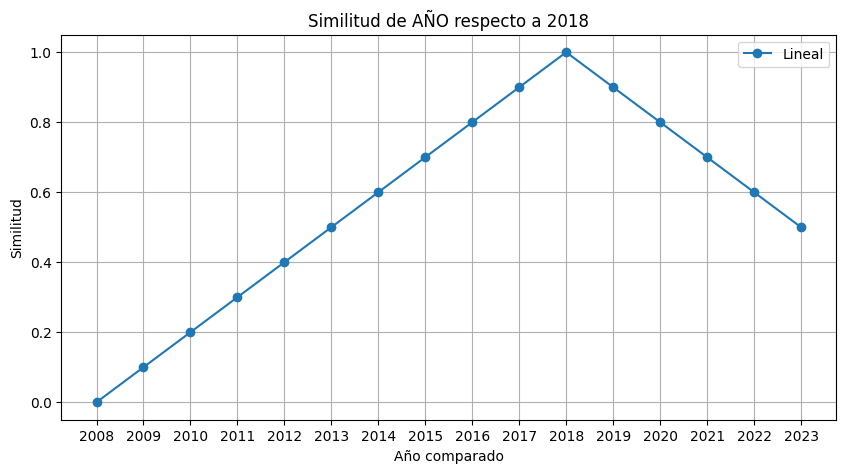

In [9]:
reference_year = 2018
years = list(range(2008, 2024))
year_sims = [year_sim_linear(reference_year, y) for y in years]
plot_year([year_sims], ['Lineal'], years, reference_year)

### **Ejercicio 1:** Comparación de métricas numéricas

Investiga las métricas numéricas `cbrkit.sim.numbers.exponential`, `cbrkit.sim.numbers.sigmoid`, `cbrkit.sim.numbers.threshold`.

1. Añadelas al código
2. Investiga los parámetros más apropiados.
3. ¿Cuál crees que es más apropiada para este dominio? Justifica tu respuesta en una celda de texto.

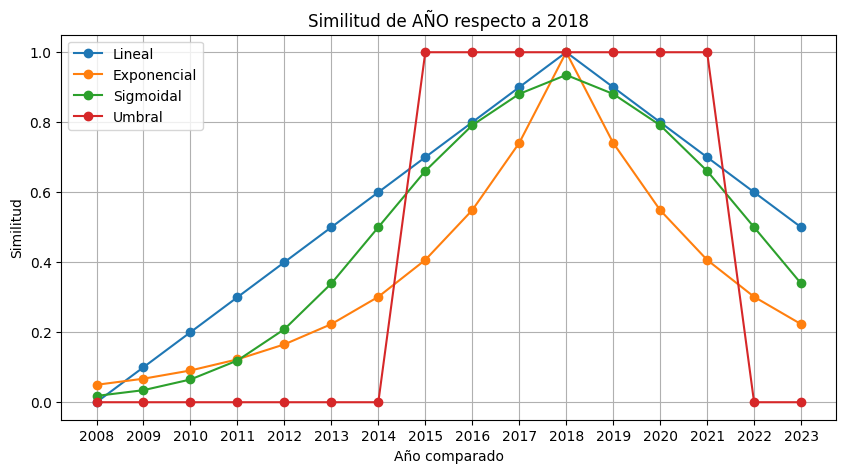

In [10]:
# Ejercicio 1: Tu código aquí
# exponencial con alpha=0.3, lo que significa que la similitud disminuirá rápidamente a medida que la diferencia de años aumente,
# penalizando más las diferencias grandes. e^−rate⋅∥x−y∥

year_sim_exponential = cbr.sim.numbers.exponential(alpha=0.3)  # similitud exponencial Calcula la similitud usando una función exponencial que penaliza más las diferencias grandes.

#sigmoidal con alpha=1.5 y theta=4.0, lo que significa que la similitud disminuirá rápidamente a medida que la diferencia de años
# se acerque a 4, y luego se estabilizará para diferencias mayores. 

year_sim_sigmoid = cbr.sim.numbers.sigmoid(alpha=1.5,theta=4.0)  # Similitud sigmoidal  Calcula la similitud usando una función sigmoidal que suaviza las diferencias, con un punto de inflexión definido por theta.

# umbral con valor de 3 años supone que coches con una diferencia de 3 años o menos son considerados similares, 
# mientras que aquellos con una diferencia mayor a 3 años no lo son. 1 si |x−y| ≤ threshold, 0 en caso contrario
year_sim_threshold = cbr.sim.numbers.threshold(value=3)  # similitud umbral Calcula la similitud usando una función de umbral que devuelve 1.0 si la diferencia es menor que un valor específico, y 0.0 en caso contrario.

# Compara las métricas
reference_year = 2018
years = list(range(2008, 2024))

linear_sims = [year_sim_linear(reference_year, y) for y in years]
exp_sims = [year_sim_exponential(reference_year, y) for y in years]
sig_sims = [year_sim_sigmoid(reference_year, y) for y in years]
thr_sims = [year_sim_threshold(reference_year, y) for y in years]


plot_year([linear_sims, exp_sims, sig_sims, thr_sims], ['Lineal', 'Exponencial', 'Sigmoidal', 'Umbral'], years, reference_year)



*Escribe aquí tu análisis del Ejercicio 1...*
Para este dominio la más apropiada es la funcion sigmoidial s(d)= 1/e^(alpha⋅(∥x−y∥−theta)) + 1 donde a partir de los 4 años empieza a penalizar y con una pendiente no muy abruta generando una funcion acorde con la similitud de los coches año a año.

La exponencial seria más relevante para donde cualquier diferencia es relevante desde el inicio

La linear subestima las diferencias grandes siendo muy constante

La umbral es muy rigida.

### 3.2 Métricas para atributos categóricos (`cbrkit.sim.generic`)

Para atributos como `fuel`, `transmission` o `condition` podemos usar:
- **`equality`**: 1.0 si son iguales, 0.0 si no lo son.
- **`table`**: define similitudes personalizadas entre pares de valores.
- Una función personalizada.

In [11]:
# Métrica de igualdad (la más básica para categóricos)
equality_sim = cbr.sim.generic.equality()

print("=== Similitud de COMBUSTIBLE (igualdad) ===")
fuels = [("gas", "gas"), ("gas", "electric"), ("gas", "hybrid"), ("electric", "electric")]
for x, y in fuels:
    print(f"  sim({x}, {y}) = {equality_sim(x, y):.1f}")

=== Similitud de COMBUSTIBLE (igualdad) ===
  sim(gas, gas) = 1.0
  sim(gas, electric) = 0.0
  sim(gas, hybrid) = 0.0
  sim(electric, electric) = 1.0


In [12]:
# Métrica de tabla: permite definir similitudes parciales entre valores categóricos
# Útil cuando hay una relación semántica entre las categorías

# Para el atributo 'condition', hay un orden natural: excellent > good > fair > salvage
condition_sim_table = cbr.sim.generic.table(
    {
        ("excellent", "excellent"): 1.0,
        ("excellent", "good"):      0.7,
        ("excellent", "fair"):      0.3,
        ("excellent", "salvage"):   0.0,
        ("good",      "excellent"): 0.7,
        ("good",      "good"):      1.0,
        ("good",      "fair"):      0.5,
        ("good",      "salvage"):   0.1,
        ("fair",      "excellent"): 0.3,
        ("fair",      "good"):      0.5,
        ("fair",      "fair"):      1.0,
        ("fair",      "salvage"):   0.2,
        ("salvage",   "excellent"): 0.0,
        ("salvage",   "good"):      0.1,
        ("salvage",   "fair"):      0.2,
        ("salvage",   "salvage"):   1.0,
    },
    default=0.0
)

print("=== Similitud de CONDICIÓN (tabla personalizada) ===")
conditions = ["excellent", "good", "fair", "salvage"]
for c1 in conditions:
    for c2 in conditions:
        sim = condition_sim_table(c1, c2)
        print(f"  sim({c1:10s}, {c2:10s}) = {sim:.1f}")

=== Similitud de CONDICIÓN (tabla personalizada) ===
  sim(excellent , excellent ) = 1.0
  sim(excellent , good      ) = 0.7
  sim(excellent , fair      ) = 0.3
  sim(excellent , salvage   ) = 0.0
  sim(good      , excellent ) = 0.7
  sim(good      , good      ) = 1.0
  sim(good      , fair      ) = 0.5
  sim(good      , salvage   ) = 0.1
  sim(fair      , excellent ) = 0.3
  sim(fair      , good      ) = 0.5
  sim(fair      , fair      ) = 1.0
  sim(fair      , salvage   ) = 0.2
  sim(salvage   , excellent ) = 0.0
  sim(salvage   , good      ) = 0.1
  sim(salvage   , fair      ) = 0.2
  sim(salvage   , salvage   ) = 1.0


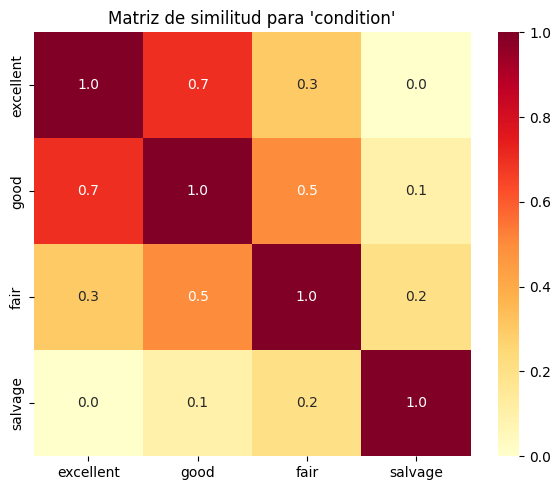

In [13]:
# Visualizar la matriz de similitud para 'condition'
conditions = ["excellent", "good", "fair", "salvage"]
matrix = [[condition_sim_table(c1, c2) for c2 in conditions] for c1 in conditions]
matrix_df = pd.DataFrame(matrix, index=conditions, columns=conditions)

plt.figure(figsize=(6, 5))
sns.heatmap(matrix_df, annot=True, fmt=".1f", cmap="YlOrRd", vmin=0, vmax=1)
plt.title("Matriz de similitud para 'condition'")
plt.tight_layout()
plt.show()

### **Ejercicio 2:** Métrica para el atributo `fuel`

La igualdad exacta para `fuel` puede ser demasiado estricta. Por ejemplo, `hybrid` es más cercano a `electric` que a `gas`.

1. Crea una **métrica de tabla** para el atributo `fuel` que tenga en cuenta estas similitudes parciales.
2. Visualiza la matriz de similitud resultante.
3. Justifica tus elecciones de valores en una celda de texto.

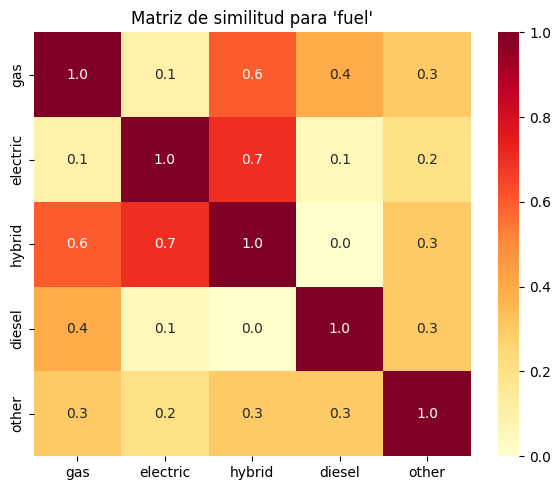

In [14]:
# Ejercicio 2: Tu código aquí
# Valores posibles de fuel: gas, electric, hybrid, diesel, other

fuel_sim = cbr.sim.generic.table(
    {
        # TODO: Define las similitudes entre tipos de combustible
        # Recuerda: sim(x, x) = 1.0 siempre
        # ¿Cuánto se parece 'hybrid' a 'gas'? ¿Y 'diesel' a 'gas'?
        ("gas",      "gas"):      1.0,
        ("electric", "electric"): 1.0,
        ("hybrid",   "hybrid"):   1.0,
        ("diesel",   "diesel"):   1.0,
        ("other",    "other"):    1.0,
        ("hybrid",   "gas"):      0.6,
        ("gas",      "hybrid"):   0.6,
        ("hybrid",   "electric"): 0.7,
        ("electric", "hybrid"):   0.7,
        ("gas",      "diesel"):   0.4,
        ("diesel",   "gas"):      0.4,
        ("electric", "gas"):      0.1,
        ("gas",      "electric"): 0.1,
        ("electric", "diesel"):   0.05,
        ("diesel",   "electric"): 0.05,
        ("other",    "gas"):      0.3,
        ("gas",      "other"):    0.3,
        ("other",    "hybrid"):   0.3,
        ("hybrid",   "other"):    0.3,
        ("other",    "electric"): 0.2,
        ("electric", "other"):    0.2,
        ("other",    "diesel"):   0.3,
        ("diesel",   "other"):    0.3,

    },
    default=0.0
)

# TODO: Visualiza la matriz de similitud
fuels = ["gas", "electric", "hybrid", "diesel", "other"]
matrix = [[fuel_sim(f1, f2) for f2 in fuels] for f1 in fuels]
matrix_df = pd.DataFrame(matrix, index=fuels, columns=fuels)

plt.figure(figsize=(6, 5))
sns.heatmap(matrix_df, annot=True, fmt=".1f", cmap="YlOrRd", vmin=0, vmax=1)

plt.title("Matriz de similitud para 'fuel'")
plt.tight_layout()
plt.show()
          

*Escribe aquí tu justificación del Ejercicio 2...*
Los valores reflejan la similirud entre tecnologías. hybrid y electric=0.7 al ser el motot electrico es un comoponete central entre ambos 
hybrid y gas parecido. gas y diesel son ambos motores de combustion pero con gran diferencia en mecanica y compuesto.Por ultimo entre electric y gas o diesel son tecnologias opuestas 


### 3.3 Métricas para atributos de texto (`cbrkit.sim.strings`)

El atributo `model` es una cadena de texto libre (ej. "camry se", "camry xse"). Para compararlo usaremos métricas de similitud de strings:

In [15]:
# Métricas de similitud de cadenas disponibles en CBRkit
# Necesitamos instalar la dependencia 'nlp' de cbrkit para Levenshtein y Jaro
%pip install levenshtein --quiet

Note: you may need to restart the kernel to use updated packages.


In [16]:
# Métrica de Levenshtein: basada en distancia de edición
levenshtein_sim = cbr.sim.strings.levenshtein()

# Métrica de Jaro-Winkler: mejor para nombres y cadenas cortas
jaro_sim = cbr.sim.strings.jaro_winkler()

print("=== Comparación de métricas de STRING para 'model' ===")
model_pairs = [
    ("camry se", "camry se"),       # igual
    ("camry se", "camry le"),       # muy similar (mismo modelo, trim diferente)
    ("camry se", "camry xse"),      # similar
    ("camry se", "corolla le"),     # misma marca, modelo diferente
    ("camry se", "f-150 xlt"),      # completamente diferente
]

print(f"{'Par':<35} {'Levenshtein':>12} {'Jaro-Winkler':>12}")
print("-" * 62)
for x, y in model_pairs:
    lev = levenshtein_sim(x, y)
    jaro = jaro_sim(x, y)
    print(f"  ({x!r}, {y!r})   {lev:>12.3f} {jaro:>12.3f}")

=== Comparación de métricas de STRING para 'model' ===
Par                                  Levenshtein Jaro-Winkler
--------------------------------------------------------------
  ('camry se', 'camry se')          1.000        1.000
  ('camry se', 'camry le')          0.875        0.950
  ('camry se', 'camry xse')          0.941        0.978
  ('camry se', 'corolla le')          0.444        0.633
  ('camry se', 'f-150 xlt')          0.118        0.412


In [17]:
# También podemos definir una función personalizada
# CBRkit exige que los parámetros se llamen x e y

def model_sim_prefix(x: str, y: str) -> float:
    """
    Similitud para el modelo del coche:
    - Coincidencia exacta: 1.0
    - La primera palabra (nombre de modelo) coincide: 0.7
    - La primera palabra NO coincide: basado en Jaro
    """
    if x == y:
        return 1.0
    x_parts = x.lower().split()
    y_parts = y.lower().split()
    if x_parts[0] == y_parts[0]:
        return 0.7
    # Si las primeras palabras son distintas, similitud baja
    return 0.1

print("=== Función personalizada 'model_sim_prefix' ===")
for x, y in model_pairs:
    sim = model_sim_prefix(x, y)
    print(f"  ({x!r}, {y!r}) => {sim:.2f}")

=== Función personalizada 'model_sim_prefix' ===
  ('camry se', 'camry se') => 1.00
  ('camry se', 'camry le') => 0.70
  ('camry se', 'camry xse') => 0.70
  ('camry se', 'corolla le') => 0.10
  ('camry se', 'f-150 xlt') => 0.10


---
## Parte 4: Pipeline de recuperación completo

Ahora combinaremos todas las métricas locales en un **pipeline de recuperación** usando `cbrkit.sim.attribute_value` para definir la similitud global, y `cbrkit.retrieval.build` para construir el retriever.

### 4.1 Primer retriever: similitud básica

In [19]:
# Definición del retriever básico
# attribute_value combina similitudes locales mediante media ponderada

base_retriever = cbr.retrieval.build(
    cbr.sim.attribute_value(
        attributes={
            "year":         year_sim_linear,
            "odometer":     odometer_sim_linear,
            "manufacturer": equality_sim,
            "fuel":         equality_sim,
            "transmission": equality_sim,
            "condition":    equality_sim,
            "model":        levenshtein_sim,
        },
        aggregator=cbr.sim.aggregator(pooling="mean", 
            pooling_weights={
            "year":         0.20,
            "odometer":     0.20,
            "manufacturer": 0.20,
            "fuel":         0.10,
            "transmission": 0.05,
            "condition":    0.15,
            "model":        0.10,
        })
    )
)
retriever_basic = cbr.retrieval.dropout(base_retriever, limit=5)
print("Retriever básico construido")

Retriever básico construido


In [20]:
# Ejecutar la recuperación para la primera consulta
query = queries["query_1"]
print(f"Consulta: {query['year']} {query['manufacturer']} {query['model']}")
print(f"         Condición: {query['condition']}, Kilometraje: {query['odometer']:,}\n")

result = cbr.retrieval.apply.apply_query(casebase, query, retriever_basic)

step  = result.steps[-1]
qstep = list(step.queries.values())[0]

print(f"{'ID':>4} {'Año':>5} {'Marca':>12} {'Modelo':>22} {'Precio':>8} {'Similitud':>10}")
print("-" * 70)
for case_id in qstep.ranking:
    sim_val = float(qstep.similarities[case_id].value)
    case = casebase[case_id]
    print(f"{case_id:>4} {case['year']:>5} {case['manufacturer']:>12} "
          f"{case['model']:>22} {case['price']:>8,} {sim_val:>10.4f}")

Consulta: 2018 toyota camry le
         Condición: good, Kilometraje: 50,000

  ID   Año        Marca                 Modelo   Precio  Similitud
----------------------------------------------------------------------
   0  2018       toyota               camry se   18,500     0.9808
   5  2017       toyota             corolla le   13,500     0.9302
  39  2014       toyota          highlander le   18,000     0.8316
  13  2019       toyota               rav4 xle   27,000     0.7453
  30  2020       toyota              camry xse   26,000     0.7417


In [21]:
(a, b) = result
b

('duration', 0.012147400004323572)

### 4.2 Segundo retriever: métricas mejoradas

Ahora construiremos un segundo retriever que use las métricas más elaboradas que hemos definido.

In [22]:
# Retriever mejorado con las métricas personalizadas
# NOTA: Antes de ejecutar esto, asegúrate de haber completado el Ejercicio 2
# Si no, puedes usar equality_sim para fuel como placeholder

base_retriever_improved = cbr.retrieval.build(
    cbr.sim.attribute_value(
        attributes={
            "year":         year_sim_exponential,   # función exponencial personalizada
            "odometer":     odometer_sim_linear,
            "manufacturer": equality_sim,
            "fuel":         equality_sim,            # TODO: sustituir por fuel_sim del Ejercicio 2
            "transmission": equality_sim,
            "condition":    condition_sim_table,     # tabla de similitud semántica
            "model":        model_sim_prefix,        # función personalizada de prefijos
        },
        aggregator=cbr.sim.aggregator(pooling="mean", 
            pooling_weights={
            "year":         0.20,
            "odometer":     0.20,
            "manufacturer": 0.20,
            "fuel":         0.10,
            "transmission": 0.05,
            "condition":    0.15,
            "model":        0.10,
        })
    )
)


retriever_improved = cbr.retrieval.dropout(base_retriever_improved, limit=5)
print("Retriever mejorado construido")


result = cbr.retrieval.apply.apply_query(casebase, query, retriever_improved)

step  = result.steps[-1]
qstep = list(step.queries.values())[0]


print("Top-5 con retriever MEJORADO:")
tep  = result.steps[-1]
qstep = list(step.queries.values())[0]

print(f"{'ID':>4} {'Año':>5} {'Marca':>12} {'Modelo':>22} {'Precio':>8} {'Similitud':>10}")
print("-" * 70)
for case_id in qstep.ranking:
    sim_val = float(qstep.similarities[case_id].value)
    case = casebase[case_id]
    print(f"{case_id:>4} {case['year']:>5} {case['manufacturer']:>12} "
          f"{case['model']:>22} {case['price']:>8,} {sim_val:>10.4f}")

Retriever mejorado construido
Top-5 con retriever MEJORADO:
  ID   Año        Marca                 Modelo   Precio  Similitud
----------------------------------------------------------------------
   0  2018       toyota               camry se   18,500     0.9633
   5  2017       toyota             corolla le   13,500     0.8528
  30  2020       toyota              camry xse   26,000     0.7841
  13  2019       toyota               rav4 xle   27,000     0.7785
  39  2014       toyota          highlander le   18,000     0.7342


### **Ejercicio 3:** Comparación de retrievers

1. Ejecuta ambos retrievers (básico y mejorado) sobre otras tres consultas distintas.
2. Para cada consulta, muestra una tabla comparando el top-3 recuperado por cada retriever.
3. ¿Los resultados difieren significativamente? ¿Cuándo las mejoras son más notables?

In [24]:
def mostrar_top3(retriever, label, query_id):
    query  = queries[query_id]
    result = cbr.retrieval.apply.apply_query(casebase, query, retriever)
    step   = result.steps[-1]
    qstep  = list(step.queries.values())[0]

    print(f"\n  [{label}]")
    print(f"  {'ID':>4} {'Año':>5} {'Marca':>12} {'Modelo':>20} {'Precio':>8} {'Sim':>8}")
    print("  " + "-"*62)
    for case_id in qstep.ranking[:3]:
        sim = float(qstep.similarities[case_id].value)
        c   = casebase[case_id]
        print(f"  {case_id:>4} {c['year']:>5} {c['manufacturer']:>12} "
              f"{c['model']:>20} {c['price']:>8,} {sim:>8.4f}")


# Comparación para las 3 queries
for qid in ["query_1", "query_2", "query_3"]:
    q = queries[qid]
    print(f"\n{'='*65}")
    print(f"  {qid}: {q['year']} {q['manufacturer']} {q['model']}")
    print(f"  Condición: {q['condition']} | Km: {q['odometer']:,} | Fuel: {q['fuel']}")
    mostrar_top3(retriever_basic,    "BÁSICO   ", qid)
    mostrar_top3(retriever_improved, "MEJORADO ", qid)



  query_1: 2018 toyota camry le
  Condición: good | Km: 50,000 | Fuel: gas

  [BÁSICO   ]
    ID   Año        Marca               Modelo   Precio      Sim
  --------------------------------------------------------------
     0  2018       toyota             camry se   18,500   0.9808
     5  2017       toyota           corolla le   13,500   0.9302
    39  2014       toyota        highlander le   18,000   0.8316

  [MEJORADO ]
    ID   Año        Marca               Modelo   Precio      Sim
  --------------------------------------------------------------
     0  2018       toyota             camry se   18,500   0.9633
     5  2017       toyota           corolla le   13,500   0.8528
    30  2020       toyota            camry xse   26,000   0.7841

  query_2: 2020 tesla model 3 long range
  Condición: excellent | Km: 10,000 | Fuel: electric

  [BÁSICO   ]
    ID   Año        Marca               Modelo   Precio      Sim
  --------------------------------------------------------------
    

*Escribe aquí tu análisis del Ejercicio 3...*

Las diferencias más notables aparecen en query_2 (Tesla eléctrico): el retriever básico con equality para fuel puede recuperar coches de gasolina si su año y kilometraje son similares, mientras que el mejorado con fuel_sim penalizará más fuertemente esa diferencia tecnológica.

EN la query 3 el retriever mejorado recupera conches en estado good con similitud 0.5 mientras que el basico agina 0



### **Ejercicio 4:** Efecto de los pesos en el retrieval

Los pesos en `pooling_weights` controlan la importancia relativa de cada atributo en la similitud global.

1. Crea un tercer retriever `retriever_km_focused` donde el kilometraje tenga un peso de **0.40** (reduce los otros atributos proporcionalmente).
2. Compara sus resultados con el retriever mejorado para `query_3` (el coche con mayor kilometraje).
3. ¿Qué atributos tienen mayor impacto en los resultados?

In [25]:
# Ejercicio 4: Retriever con mayor peso en kilometraje

base_retriever_km = cbr.retrieval.build(
    cbr.sim.attribute_value(
        attributes={
            "year":         year_sim_exponential,
            "odometer":     odometer_sim_linear,
            "manufacturer": equality_sim,
            "fuel":         fuel_sim,             # del Ejercicio 2
            "transmission": equality_sim,
            "condition":    condition_sim_table,
            "model":        model_sim_prefix,
        },
        aggregator=cbr.sim.aggregator(
            pooling="mean",
            pooling_weights={
                "year":         0.15,   # reducido de 0.20
                "odometer":     0.40,   # AUMENTADO: prioridad máxima al km
                "manufacturer": 0.15,   # reducido de 0.20
                "fuel":         0.10,   # sin cambio
                "transmission": 0.05,   # sin cambio
                "condition":    0.10,   # reducido de 0.15
                "model":        0.05,   # reducido de 0.10
            }
        )
    )
)

retriever_km_focused = cbr.retrieval.dropout(base_retriever_km, limit=5)

# Comparación para query_3 (mayor kilometraje: Honda Civic 85,000 km)
print("COMPARACIÓN PARA QUERY_3 (Honda Civic, fair, 85,000 km)")
mostrar_top3(retriever_improved,  "MEJORADO    ", "query_3")
mostrar_top3(retriever_km_focused,"KM-FOCUSED  ", "query_3")


COMPARACIÓN PARA QUERY_3 (Honda Civic, fair, 85,000 km)

  [MEJORADO    ]
    ID   Año        Marca               Modelo   Precio      Sim
  --------------------------------------------------------------
     1  2016        honda             civic lx   14,200   0.8125
    21  2015        honda               fit lx   10,200   0.8097
     6  2014        honda         accord sport   11,800   0.7738

  [KM-FOCUSED  ]
    ID   Año        Marca               Modelo   Precio      Sim
  --------------------------------------------------------------
    21  2015        honda               fit lx   10,200   0.8543
     6  2014        honda         accord sport   11,800   0.8475
     1  2016        honda             civic lx   14,200   0.8348


---
## Parte 5: Adaptación de la solución (Reuse)

Una vez recuperados los casos más similares, la etapa de **Reuse** adapta su solución al nuevo problema. En nuestro dominio, la "solución" es el **precio** del vehículo.

Implementaremos una función de adaptación que **estima el precio** del vehículo consulta en base a los casos recuperados.

### 5.1 Adaptación simple: media ponderada de precios

In [26]:
# Función de adaptación: media ponderada de precios por similitud
# En CBRkit, una función de reuse acepta (case, query) y devuelve el caso adaptado

def adapt_price_weighted_mean(case: dict, query: dict) -> dict:
    """
    Adaptación trivial: devuelve el precio del caso más similar sin modificación.
    Este es el caso más simple de reuse (copia directa).
    """
    adapted = dict(case)  # copia del caso
    # El precio no se adapta, se reutiliza directamente
    return adapted

print("Función de adaptación básica definida")

# Construcción del pipeline completo: retrieval + reuse
reuser_basic = cbr.reuse.build(adapt_price_weighted_mean, retriever_basic)
print("Reuser construido")

Función de adaptación básica definida
Reuser construido


In [28]:
# Pipeline completo: primero retrieve, luego reuse
query = queries["query_1"]


# Paso 2: Reuse (adaptación trivial - precio directo)
reuse_result = cbr.retrieval.apply.apply_query(casebase, query, retriever_basic)

step  = result.steps[-1]
qstep = list(step.queries.values())[0]

print(f"{'ID':>4} {'Año':>5} {'Marca':>12} {'Modelo':>22} {'Precio':>8} {'Similitud':>10}")
print("-" * 70)
for case_id in qstep.ranking:
    sim_val = float(qstep.similarities[case_id].value)
    case = casebase[case_id]
    print(f"{case_id:>4} {case['year']:>5} {case['manufacturer']:>12} "
          f"{case['model']:>22} {case['price']:>8,} {sim_val:>10.4f}")


  ID   Año        Marca                 Modelo   Precio  Similitud
----------------------------------------------------------------------
   0  2018       toyota               camry se   18,500     0.9633
   5  2017       toyota             corolla le   13,500     0.8528
  30  2020       toyota              camry xse   26,000     0.7841
  13  2019       toyota               rav4 xle   27,000     0.7785
  39  2014       toyota          highlander le   18,000     0.7342


In [ ]:
reuse_result

### **Ejercicio 5:** Implementa tu propia función de adaptación

La función de adaptación anterior solo considera año, kilometraje y condición. Mejórala añadiendo:

1. Una corrección cuando el **tipo de combustible** es diferente (ej., los coches eléctricos suelen ser más caros que los de gasolina equivalentes).
2. Una corrección cuando el **fabricante** es distinto (ej., marcas de lujo como BMW tienen precios más altos).
3. Prueba tu función de adaptación mejorada en las tres consultas y compara los precios estimados con la versión anterior.

In [ ]:
# Ejercicio 5: Función de adaptación avanzada

FUEL_PRICE_FACTOR = {
    "electric": 1.15,   # eléctricos ~15% más caros por tecnología de batería
    "hybrid":   1.05,   # híbridos ~5% más caros
    "gas":      1.00,   # referencia base
    "diesel":   1.02,   # diesel ligeramente más caro en EE.UU.
    "other":    0.95,   # otros con descuento por incertidumbre
}

MANUFACTURER_TIER = {
    # Premium: marcas de lujo con mayor valor residual
    "bmw":             1.20,
    "tesla":           1.20,
    "mercedes-benz":   1.20,
    "audi":            1.20,
    "lexus":           1.15,
    # Mid: marcas mainstream con buen valor residual
    "toyota":          1.05,
    "honda":           1.05,
    "subaru":          1.03,
    "volkswagen":      1.02,
    # Budget: marcas con depreciación más rápida
    "ford":            0.95,
    "chevrolet":       0.92,
    "nissan":          0.93,
    "hyundai":         0.92,
    "kia":             0.91,
}

def adapt_price_advanced_v2(case: dict, query: dict) -> dict:
    """
    Adaptación mejorada con correcciones por año, km, combustible y marca.
    Devuelve el caso con el precio estimado para la query.
    """
    base_price = case.get("price", 0)
    if base_price is None or base_price == 0:
        return dict(case)

    # 1. Corrección por año: depreciación ~8% anual (valor típico de mercado)
    year_diff = query["year"] - case["year"]   # positivo = query más nuevo
    depreciation_rate = 0.08
    year_factor = (1 + depreciation_rate) ** year_diff
    # Limitar el factor a rango razonable [0.4, 2.5]
    year_factor = max(0.4, min(2.5, year_factor))

    # 2. Corrección por kilometraje: ~$0.08 por km de diferencia
    km_diff = case["odometer"] - query["odometer"]   # positivo = caso tiene más km
    km_correction = km_diff * 0.08   # el caso usado tiene más km → precio sube para la query
    adjusted_price = base_price + km_correction

    # 3. Corrección por combustible: relativa al combustible del caso
    fuel_query = FUEL_PRICE_FACTOR.get(query.get("fuel", "gas"), 1.0)
    fuel_case  = FUEL_PRICE_FACTOR.get(case.get("fuel",  "gas"), 1.0)
    fuel_factor = fuel_query / fuel_case   # ratio entre el segmento de la query y el del caso

    # 4. Corrección por fabricante
    manuf_query = MANUFACTURER_TIER.get(query.get("manufacturer", "ford"), 0.95)
    manuf_case  = MANUFACTURER_TIER.get(case.get("manufacturer",  "ford"), 0.95)
    manuf_factor = manuf_query / manuf_case

    # Precio final estimado
    estimated_price = adjusted_price * year_factor * fuel_factor * manuf_factor
    estimated_price = round(max(500, estimated_price), -2)   # mínimo $500, redondeado a centenas

    adapted = dict(case)
    adapted["price"] = int(estimated_price)
    adapted["_price_original"] = base_price   # guardamos el original para comparar
    return adapted


# Construir el reuser con la función mejorada
reuser_v2 = cbr.reuse.build(adapt_price_advanced_v2, retriever_improved)

# Probar en las 3 consultas
for qid in ["query_1", "query_2", "query_3"]:
    query = queries[qid]
    print(f"\n{'='*65}")
    print(f"QUERY: {query['year']} {query['manufacturer']} {query['model']}")
    print(f"       Condición: {query['condition']}, Km: {query['odometer']:,}, Fuel: {query['fuel']}")

    reuse_result = cbr.reuse.apply.apply_query(casebase, query, reuser_v2)
    step  = reuse_result.steps[-1]
    qstep = list(step.queries.values())[0]

    print(f"\n  {'Caso ID':>8} {'Precio caso':>12} {'Precio adaptado':>16} {'Δ Precio':>10}")
    print("  " + "-"*50)
    for case_id, adapted_case in qstep.casebase.items():
        orig  = adapted_case.get("_price_original", adapted_case["price"])
        estim = adapted_case["price"]
        delta = estim - orig
        print(f"  {case_id:>8} {orig:>12,} {estim:>16,} {delta:>+10,}")


*Escribe aquí tu análisis del Ejercicio 5...*
La función estima precios más altos cuando la query es un coche más nuevo, con menos km, de tipo eléctrico o de una marca premium. La limitación principal es que los factores son fijos y no aprenden del mercado actual; en un sistema real se ajustarían con datos históricos

---
## Parte 7: Preguntas de reflexión

Responde a las siguientes preguntas en celdas de texto adicionales:

**Q1.** ¿Qué ventajas tiene usar una tabla de similitud semántica para `condition` frente a la igualdad exacta? ¿Puedes pensar en algún dominio donde la igualdad exacta sea siempre la opción correcta?

**Q2.** Los pesos de los atributos modelan la importancia relativa de cada uno. Si el sistema está orientado a compradores que priorizan el ahorro de combustible, ¿cómo modificarías los pesos?

**Q3.** La función de adaptación asume una depreciación lineal por año y por kilómetro. ¿Es esta una suposición razonable? ¿Qué modelo de depreciación sería más realista?

**Q4.** ¿Cómo implementarías la fase de **Retain** en este sistema? ¿Bajo qué condiciones añadirías un nuevo caso a la base?

**Q5.** CBRkit soporta embedding semántico (`cbrkit.sim.embed`) para comparar textos. ¿En qué situaciones del dominio del coche podría ser útil? ¿Qué limitaciones tendría?

**Q1.** *Tu respuesta aquí...*
La tabla semántica para condition recupera coches en estado good cuando la query busca excellent (con similitud 0.7), en lugar de descartar toda la base excepto los excellent. Esto aumenta el recall del sistema: es mejor proponer un coche casi perfecto que no proponer nada. La igualdad exacta es apropiada cuando las categorías son mutuamente excluyentes sin relacion ejemplo rojo es distinto de axul

**Q2.** *Tu respuesta aquí...*
Para compradores orientados al ahorro de combustible, se aumentaría el peso de fuel a 0.30–0.35 y se reduciría el de atributos menos relevantes para ese perfil (model, transmission). Adicionalmente, se podría usar la tabla fuel_sim que penaliza fuertemente la diferencia entre electric y gas.

**Q3.** *Tu respuesta aquí...*
La depreciación lineal por año y por kilómetro es una simplificación útil pero inexacta. En la realidad, la depreciación sigue una curva exponencial decreciente: el primer año un coche nuevo pierde ~20% de su valor 

**Q4.** *Tu respuesta aquí...*
La fase Retain se implementaría guardando el nuevo caso en la base solo si se cumplen tres condiciones: primero la solución fue validada (el usuario aceptó el precio estimado o se conoce el precio real de venta), segundo el caso es suficientemente novedoso (su similitud máxima con cualquier caso existente es menor que un umbral, por ej. 0.85, para evitar redundancia) y por ultimo se pasa un control de calidad mínimo (atributos completos, precio dentro de rango razonable).

**Q5.** *Tu respuesta aquí...*
Los embeddings semánticos (cbrkit.sim.embed) serían útiles en este dominio principalmente para comparar descripciones textuales libres que a veces acompañan los anuncios, donde palabras diferentes pueden expresar el mismo concepto. Tambien para comparar modelos no estandarizados (F150 y F-150 XLT)

La limitación es el coste computacional (calcular embeddings es órdenes de magnitud más lento que Levenshtein)